In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import dask
import gcsfs
from dask.distributed import Client

client = Client(n_workers=4, threads_per_worker=1, memory_limit="25GB")
print(client)

<Client: 'tcp://127.0.0.1:34915' processes=4 threads=4, memory=93.13 GiB>


In [3]:
# ds = xr.load_dataset("data/3682eec6833c1e221c339c7db7e48c16.nc")
ds = xr.load_dataset("data/350245ab986f2bb4c24c79a0a50dd6d4.nc")

In [4]:
lsm = ds["lsm"].squeeze()
sea_data = ds.where(lsm < 1).drop_vars(["number", "expver"])
# land_data = ds

In [5]:
ds_coarse = ds.sel(
    latitude=slice(None, None, 4),  # Selects every 4th latitude point
    longitude=slice(None, None, 4),  # Selects every 4th longitude point
)
lsm = ds_coarse["lsm"].squeeze()
sea_data = ds_coarse.where(lsm < 1).drop_vars(["number", "expver"])

In [6]:
sea_data

<xarray.Dataset> Size: 157MB
Dimensions:     (valid_time: 552, latitude: 131, longitude: 181)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 4kB 1979-01-01 ... 2024-12-01
  * latitude    (latitude) float64 1kB 65.0 64.0 63.0 62.0 ... -63.0 -64.0 -65.0
  * longitude   (longitude) float64 1kB 120.0 121.0 122.0 ... 298.0 299.0 300.0
Data variables:
    sst         (valid_time, latitude, longitude) float32 52MB nan nan ... nan
    lsm         (valid_time, latitude, longitude) float32 52MB 0.9839 ... 0.9546
    tcwv        (valid_time, latitude, longitude) float32 52MB 1.102 ... 7.988
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-10-18T01:22 GRIB to CDM+CF via cfgrib-0.9.1...

In [7]:
import numpy as np
import xarray as xr


def _time_as_float(time: xr.DataArray, time_dim: str) -> xr.DataArray:
    # numeric seconds since first timestamp (keeps numbers small)
    return (
        (time - time.isel({time_dim: 0}))
        .astype("timedelta64[s]")
        .astype("int64")
        .astype("float64")
    )


def linear_detrend(
    obj: xr.DataArray | xr.Dataset, time_dim: str = "time"
) -> xr.DataArray | xr.Dataset:
    """
    Remove a linear trend y ~ s*(t - t̄_valid) + ȳ_valid at each grid point.
    Closed-form LS using reductions; dask-friendly; handles NaNs.
    """
    t = _time_as_float(obj[time_dim], time_dim)  # (time,)

    def _detrend_da(da: xr.DataArray) -> xr.DataArray:
        da = da.sortby(time_dim).astype("float32")
        if hasattr(da.data, "chunks"):
            da = da.chunk({time_dim: -1})  # one chunk along time
        mask = da.notnull()  # (time, ...)
        t_b = t.broadcast_like(da)  # (time, ...)
        t_mean_valid = t_b.where(mask).mean(time_dim, skipna=True)
        tc = t_b - t_mean_valid  # centered time per point
        num = (da * tc).sum(time_dim, skipna=True)
        den = (tc**2).sum(time_dim, skipna=True)
        slope = xr.where(den > 0, num / den, 0.0)
        ybar = da.mean(time_dim, skipna=True)
        trend = slope * (t_b - t_mean_valid) + ybar
        return (da - trend).astype("float32")

    return obj.map(_detrend_da) if isinstance(obj, xr.Dataset) else _detrend_da(obj)


def monthly_anom_and_z(
    detr: xr.DataArray | xr.Dataset,
    time_dim: str = "time",
    base_period: tuple[str, str] | None = None,
    ddof: int = 1,
    eps: float = 1e-6,
):
    """
    From linearly-detrended data, remove monthly climatology and compute monthly z-scores.
    Returns (anom, z). Works for Dataset or DataArray.
    """
    clim_src = (
        detr if base_period is None else detr.sel({time_dim: slice(*base_period)})
    )
    key = f"{time_dim}.month"

    clim_mean = clim_src.groupby(key).mean(time_dim, skipna=True)
    anom = detr.groupby(key) - clim_mean

    clim_std = clim_src.groupby(key).std(time_dim, skipna=True, ddof=ddof)
    safe_std = xr.where(clim_std > eps, clim_std, np.nan)
    z = anom.groupby(key) / safe_std
    return anom, z

In [ ]:
ds_sea_data = sea_data.chunk({"valid_time": -1})
detr = linear_detrend(ds_sea_data[["sst", "tcwv"]], time_dim="valid_time")
anom, z = monthly_anom_and_z(detr, time_dim="valid_time")
z = z.drop_vars("month").compute()
z

/data/keeling/a/mtreis2/miniconda3/envs/xarray-climate/lib/python3.13/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 200.35 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


<xarray.Dataset> Size: 105MB
Dimensions:     (valid_time: 552, latitude: 131, longitude: 181)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 4kB 1979-01-01 ... 2024-12-01
  * latitude    (latitude) float64 1kB 65.0 64.0 63.0 62.0 ... -63.0 -64.0 -65.0
  * longitude   (longitude) float64 1kB 120.0 121.0 122.0 ... 298.0 299.0 300.0
Data variables:
    sst         (valid_time, latitude, longitude) float32 52MB nan nan ... nan
    tcwv        (valid_time, latitude, longitude) float32 52MB -0.9952 ... 0....

In [64]:
from eofs.xarray import Eof
from eofs.examples import example_data_path
import cartopy.crs as ccrs
import cartopy.feature as cfeature

coslat = np.cos(np.deg2rad(z["sst"].coords["latitude"].values))
wgts = np.sqrt(coslat)[..., np.newaxis]
solver = Eof(z["sst"], weights=wgts)
# Should take about 6 minutes

In [72]:
eof5 = solver.eofsAsCorrelation(neofs=5)

/data/keeling/a/mtreis2/miniconda3/envs/xarray-climate/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/data/keeling/a/mtreis2/miniconda3/envs/xarray-climate/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/data/keeling/a/mtreis2/miniconda3/envs/xarray-climate/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/data/keeling/a/mtreis2/miniconda3/envs/xarray-climate/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('fac

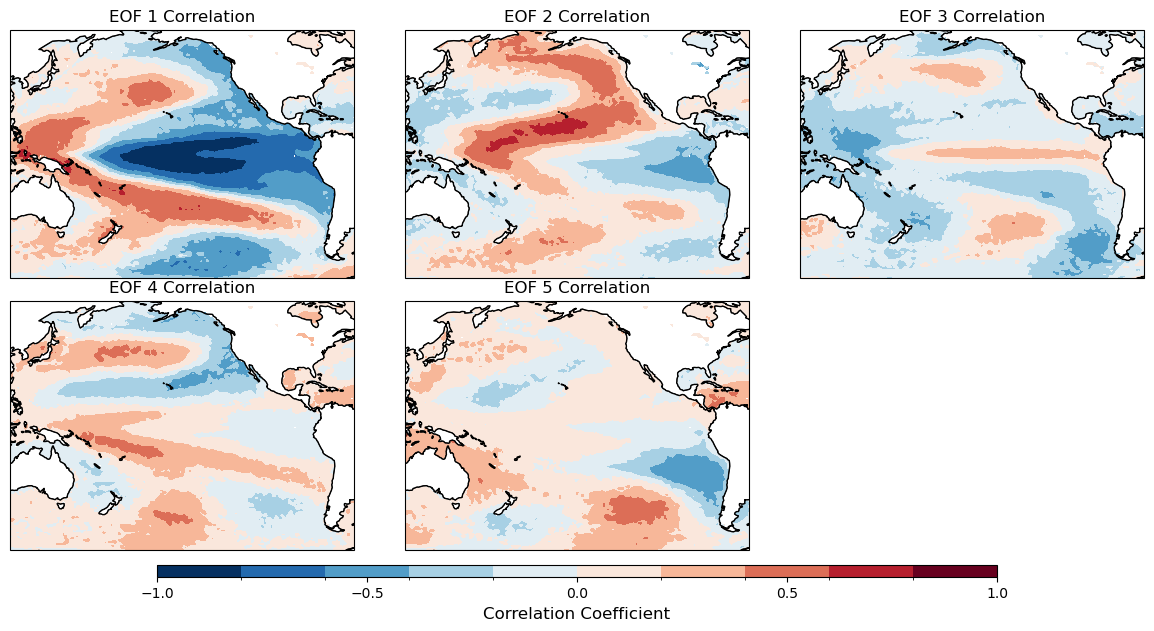

In [73]:
clevs = np.linspace(-1, 1, 11)
central_lon = 190
projection = ccrs.PlateCarree(central_longitude=central_lon)
fig, axes = plt.subplots(2, 3, figsize=(12, 6), subplot_kw={"projection": projection})
ax1 = axes[0][0]
fill = eof5.isel(mode=0).plot.contourf(
    ax=ax1,
    levels=clevs,
    cmap=plt.cm.RdBu_r,
    add_colorbar=False,
    transform=ccrs.PlateCarree(),
)
ax1.coastlines()
ax1.add_feature(cfeature.COASTLINE, color="k", edgecolor="k", linewidth=0.5)
ax1.set_title("EOF 1 Correlation", fontsize=12)

ax2 = axes[0][1]
eof5.isel(mode=1).plot.contourf(
    ax=ax2,
    levels=clevs,
    cmap=plt.cm.RdBu_r,
    add_colorbar=False,
    transform=ccrs.PlateCarree(),
)
ax2.coastlines()
ax2.add_feature(cfeature.COASTLINE, color="k", edgecolor="k", linewidth=0.5)
ax2.set_title("EOF 2 Correlation", fontsize=12)

ax3 = axes[0][2]
eof5.isel(mode=2).plot.contourf(
    ax=ax3,
    levels=clevs,
    cmap=plt.cm.RdBu_r,
    add_colorbar=False,
    transform=ccrs.PlateCarree(),
)
ax3.coastlines()
ax3.add_feature(cfeature.COASTLINE, color="k", edgecolor="k", linewidth=0.5)
ax3.set_title("EOF 3 Correlation", fontsize=12)

ax4 = axes[1][0]
eof5.isel(mode=3).plot.contourf(
    ax=ax4,
    levels=clevs,
    cmap=plt.cm.RdBu_r,
    add_colorbar=False,
    transform=ccrs.PlateCarree(),
)
ax4.coastlines()
ax4.add_feature(cfeature.COASTLINE, color="k", edgecolor="k", linewidth=0.5)
ax4.set_title("EOF 4 Correlation", fontsize=12)

ax5 = axes[1][1]
eof5.isel(mode=4).plot.contourf(
    ax=ax5,
    levels=clevs,
    cmap=plt.cm.RdBu_r,
    add_colorbar=False,
    transform=ccrs.PlateCarree(),
)
ax5.coastlines()
ax5.add_feature(cfeature.COASTLINE, color="k", edgecolor="k", linewidth=0.5)
ax5.set_title("EOF 5 Correlation", fontsize=12)

fig.delaxes(axes[1][2])

cbar_ax = fig.add_axes([0.15, 0.04, 0.7, 0.02])  # [left, bottom, width, height]
cb = plt.colorbar(
    fill,
    cax=cbar_ax,
    orientation="horizontal",
    ticks=np.linspace(-1, 1, 5),  # Use fewer ticks for clarity
)
cb.set_label("Correlation Coefficient", fontsize=12)

plt.tight_layout(rect=[0, 0.06, 1, 1])  # Make room for the colorbar
plt.show()

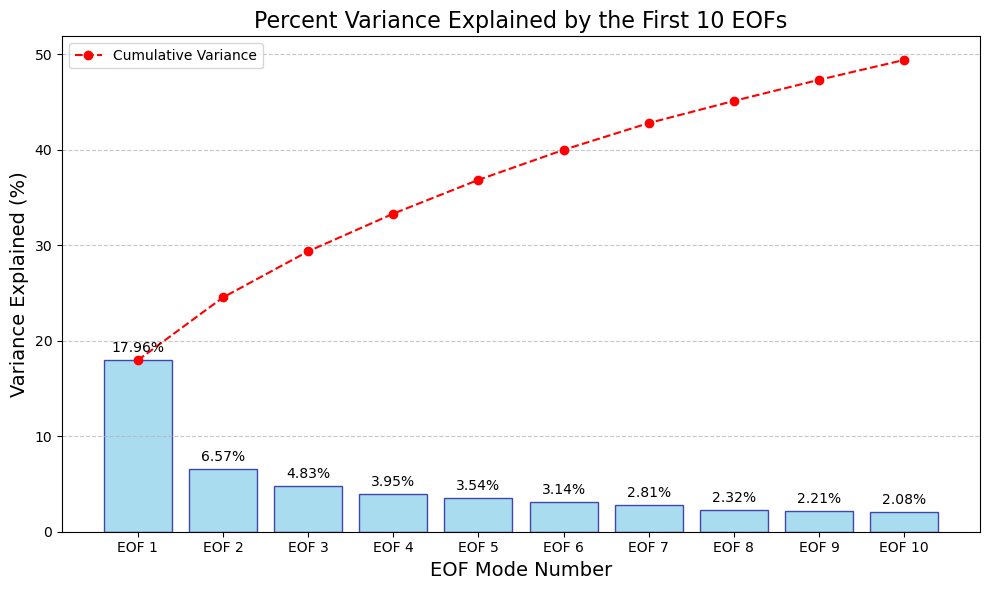

In [67]:
variance_ratio = solver.varianceFraction()[0:10] * 100
cumulative_variance = np.cumsum(variance_ratio)
eof_labels = [f"EOF {i+1}" for i in range(10)]
x_pos = np.arange(10)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(x_pos, variance_ratio, color="skyblue", edgecolor="darkblue", alpha=0.7)
ax.plot(
    x_pos,
    cumulative_variance,
    marker="o",
    color="red",
    linestyle="--",
    label="Cumulative Variance",
)

# 4. Customize the plot appearance
ax.set_xticks(x_pos)
ax.set_xticklabels(eof_labels)
ax.set_xlabel("EOF Mode Number", fontsize=14)
ax.set_ylabel("Variance Explained (%)", fontsize=14)
ax.set_title(f"Percent Variance Explained by the First 10 EOFs", fontsize=16)

# Add value labels on top of the bars
for i, v in enumerate(variance_ratio):
    ax.text(i, v + 0.5, f"{v:.2f}%", ha="center", va="bottom", fontsize=10)

ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [68]:
sst_reconstructed = solver.reconstructedField(neofs=5)

/data/keeling/a/mtreis2/miniconda3/envs/xarray-climate/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


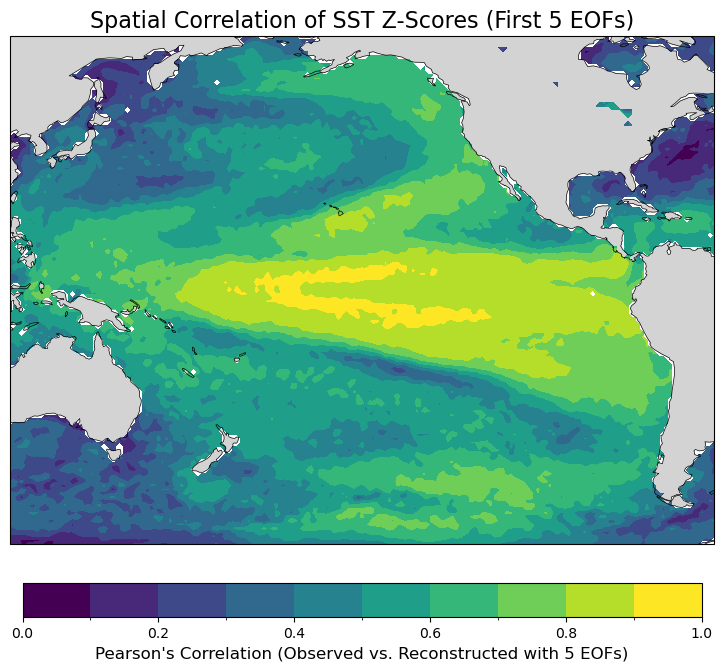

In [69]:
correlation_map = xr.corr(sst_reconstructed, z["sst"], dim="valid_time")

clevs_corr = np.linspace(0, 1, 11)
central_lon = 190

fig = plt.figure(figsize=(10, 7))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=central_lon))

fill = correlation_map.plot.contourf(
    ax=ax,
    levels=clevs_corr,
    cmap=plt.cm.viridis,
    add_colorbar=False,
    transform=ccrs.PlateCarree(),
)

ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.COASTLINE, color="k", linewidth=0.5)

cb = plt.colorbar(fill, orientation="horizontal", pad=0.06, shrink=0.7)
cb.set_label(
    f"Pearson's Correlation (Observed vs. Reconstructed with 5 EOFs)", fontsize=12
)

ax.set_title(f"Spatial Correlation of SST Z-Scores (First 5 EOFs)", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
pc1 = solver.pcs(npcs=1, pcscaling=1)
tcwv_corr_map = xr.corr(z["tcwv"], pc1, dim="valid_time").isel(mode=0)

/tmp/ipykernel_1647169/2258481283.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.06, 1, 1])


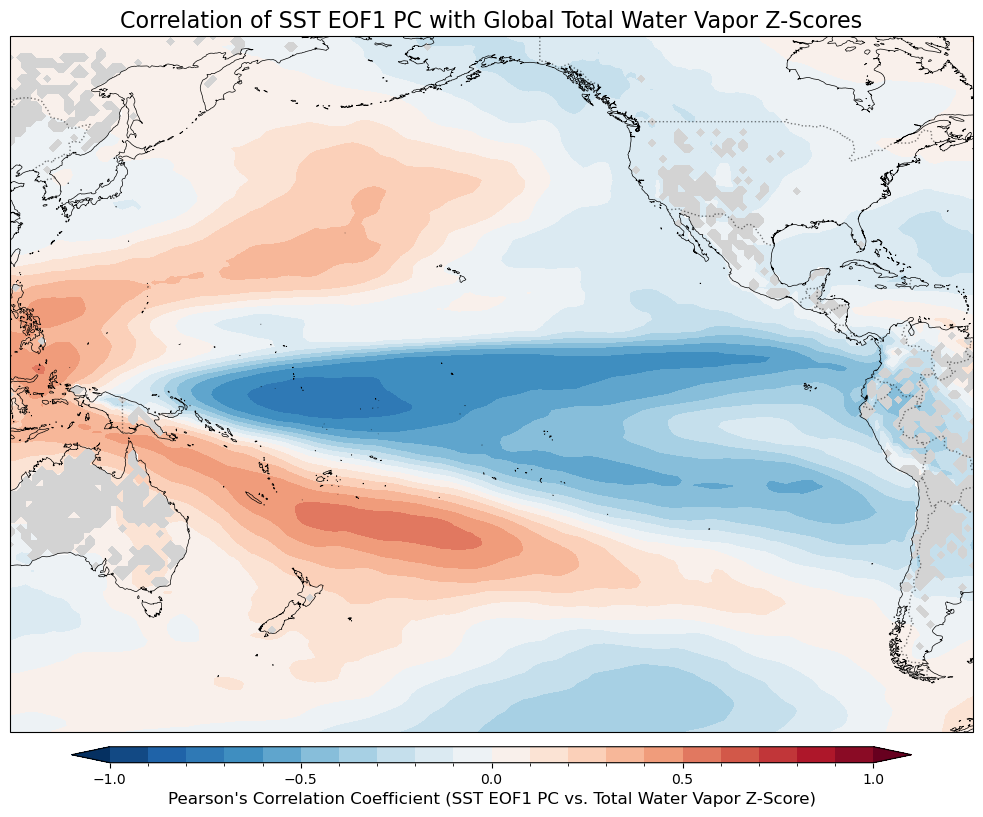

In [ ]:
fig = plt.figure(figsize=(12, 8))

central_lon = 190
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=central_lon))

clevs_corr = np.linspace(-1, 1, 21)

fill = tcwv_corr_map.plot.contourf(
    ax=ax,
    levels=clevs_corr,
    cmap=plt.cm.RdBu_r,
    extend="both",
    add_colorbar=False,
    transform=ccrs.PlateCarree(),
)

ax.coastlines(resolution="50m", color="black", linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.BORDERS, linestyle=":", alpha=0.5)

cbar_ax = fig.add_axes([0.15, 0.04, 0.7, 0.02])
cb = plt.colorbar(
    fill, cax=cbar_ax, orientation="horizontal", ticks=np.linspace(-1, 1, 5)
)
cb.set_label(
    "Pearson's Correlation Coefficient (SST EOF1 PC vs. Total Water Vapor Z-Score)",
    fontsize=12,
)

ax.set_title(
    "Correlation of SST EOF1 PC with Global Total Water Vapor Z-Scores", fontsize=16
)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()